# Sirba river selection

Selecting Sirba river from HydroSheds

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [61]:
import geopandas as gpd
import ocha_stratus as stratus

from src.datasources import hydrosheds, codab
from src.constants import *

In [11]:
adm1 = codab.load_codab_from_blob(admin_level=1)

<Axes: >

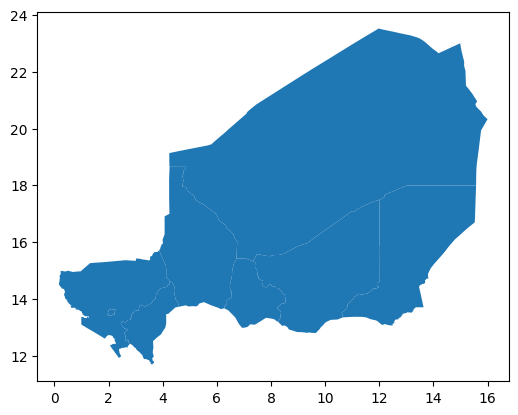

In [12]:
adm1.plot()

In [14]:
adm1_aoi = adm1[adm1["ADM1_PCODE"] == TILLABERI]

<Axes: >

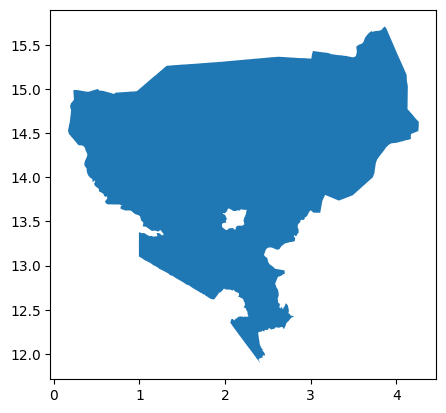

In [15]:
adm1_aoi.plot()

In [8]:
lat, lon = 13.738147, 1.615367

In [3]:
gdf = hydrosheds.load_niger_system_rivers(local=True)

<Axes: >

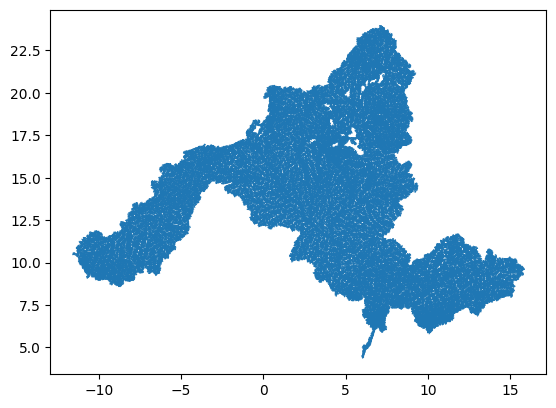

In [5]:
gdf.plot()

In [17]:
gdf_aoi = gpd.sjoin(gdf, adm1_aoi, how="inner", predicate="intersects")

<Axes: >

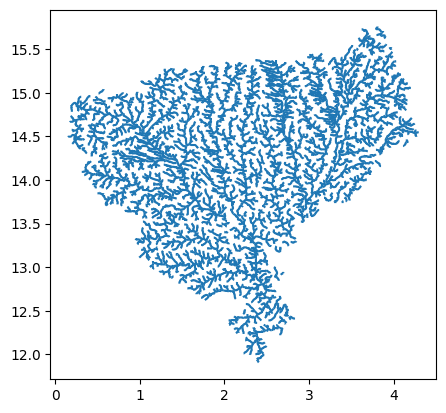

In [18]:
gdf_aoi.plot()

<Axes: >

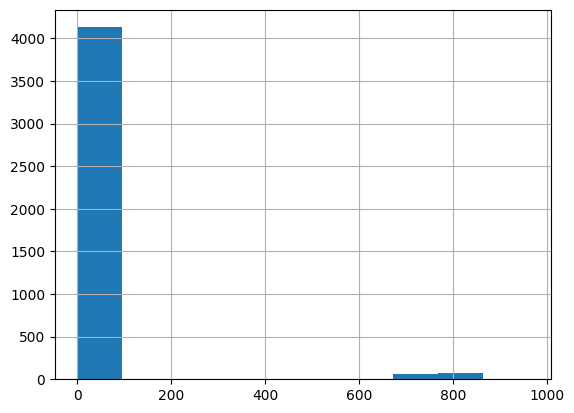

In [20]:
gdf_aoi["DIS_AV_CMS"].hist()

In [21]:
dis_thresh = 600

<Axes: >

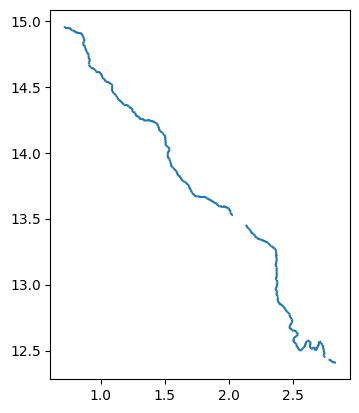

In [53]:
gdf_niger = gdf_aoi[gdf_aoi["DIS_AV_CMS"] > dis_thresh]
gdf_niger.plot()

<Axes: >

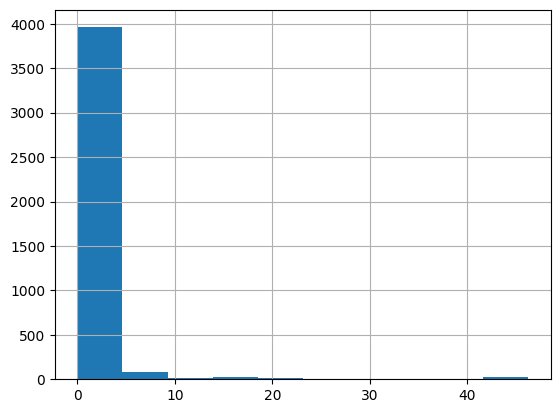

In [27]:
gdf_aoi[gdf_aoi["DIS_AV_CMS"] < dis_thresh]["DIS_AV_CMS"].hist()

In [29]:
dis_thresh_2 = 30

<Axes: >

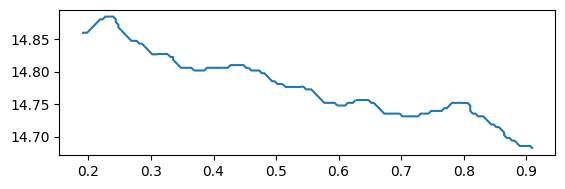

In [31]:
gdf_aoi[
    (gdf_aoi["DIS_AV_CMS"] < dis_thresh)
    & (gdf_aoi["DIS_AV_CMS"] > dis_thresh_2)
].plot()

<Axes: >

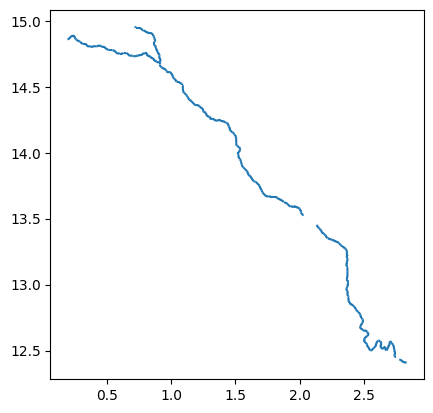

In [32]:
gdf_aoi[gdf_aoi["DIS_AV_CMS"] > dis_thresh_2].plot()

<Axes: >

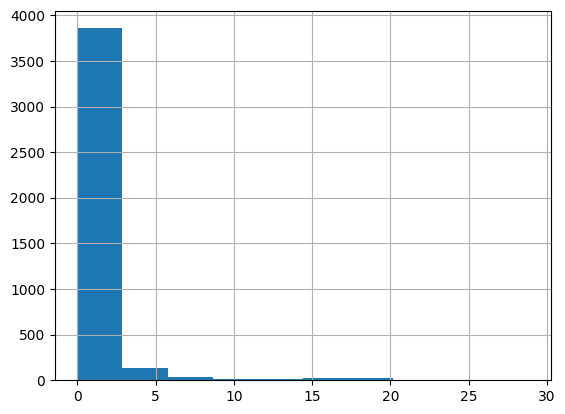

In [37]:
gdf_aoi[gdf_aoi["DIS_AV_CMS"] < dis_thresh_2]["DIS_AV_CMS"].hist()

In [51]:
gdf_selected = gdf_aoi[
    (gdf_aoi["DIS_AV_CMS"] < dis_thresh)
    & (gdf_aoi["DIS_AV_CMS"] > dis_thresh_3)
]

<Axes: >

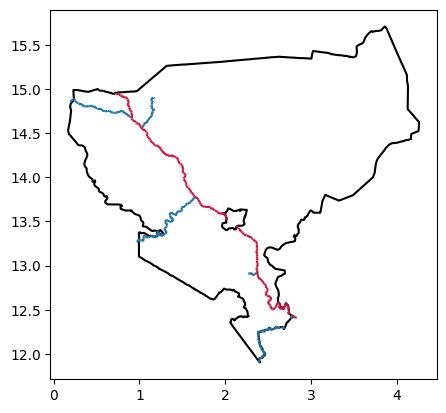

In [54]:
dis_thresh_3 = 10
ax = adm1_aoi.boundary.plot(color="k")
gdf_selected.plot(ax=ax)
gdf_niger.plot(ax=ax, color="crimson")

In [55]:
lat_min, lat_max = 13, 14

In [56]:
gdf_bounds = gdf_selected.copy()
gdf_bounds["min_lat"] = gdf_bounds.bounds.miny
gdf_bounds["max_lat"] = gdf_bounds.bounds.maxy
gdf_filtered = gdf_bounds[
    (gdf_bounds["min_lat"] >= lat_min) & (gdf_bounds["max_lat"] <= lat_max)
]

<Axes: >

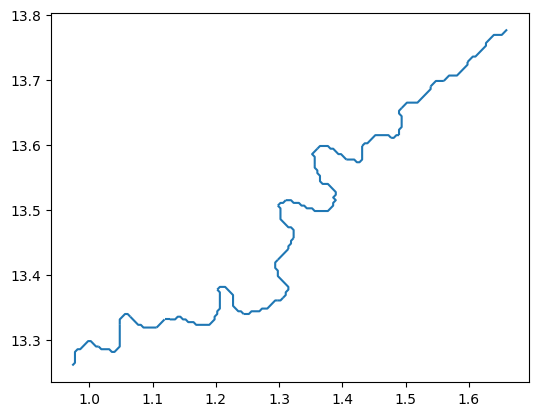

In [57]:
gdf_filtered.plot()

In [60]:
gdf_filtered

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,...,index_right,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,min_lat,max_lat
45908,10499063,10498363,10877687,9.37,1656.2,518.3,39.83,39260.9,0,16.313,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.727083,13.777083
46119,10499969,10499063,10877687,5.69,1665.4,509.1,31.28,39188.8,0,16.327,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.697917,13.727083
46186,10500252,10499969,10877687,2.64,1671.1,503.4,12.30,39091.2,0,16.288,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.689583,13.697917
46378,10501290,10500252,10877687,6.79,1673.7,500.7,43.38,39004.2,0,16.235,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.656250,13.689583
46626,10502616,10501290,10877687,5.18,1680.7,493.8,18.36,38477.6,0,15.901,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.614583,13.656250
46649,10502727,10502616,10877687,1.55,1685.7,488.8,2.29,38429.6,0,15.967,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.610417,13.614583
46751,10503105,10502727,10877687,5.93,1687.4,487.0,29.42,38300.0,0,15.888,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.597917,13.614583
46867,10503709,10503854,10877687,6.13,1698.7,475.7,22.53,38104.2,0,15.969,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.577083,13.597917
46896,10503854,10503105,10877687,5.41,1693.2,481.3,29.84,38243.9,0,15.959,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.572917,13.597917
46928,10503975,10503709,10877687,3.33,1704.9,469.6,20.24,37978.0,0,15.986,...,0,Tillabéri,NE006,Niger (the),NE,2023-06-21,2023-07-25,NaT,13.568750,13.593750


In [62]:
blob_name = f"{PROJECT_PREFIX}/processed/hydrosheds/sirba_river_in_niger"
stratus.upload_shp_to_blob(gdf_filtered, blob_name)

/Users/tdowning/.pyenv/versions/pa-aa-ner-flooding/lib/python3.11/site-packages/ocha_stratus/azure_blob.py:213: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shp_base_path, driver="ESRI Shapefile")
/Users/tdowning/.pyenv/versions/pa-aa-ner-flooding/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
/Users/tdowning/.pyenv/versions/pa-aa-ner-flooding/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field DATE create as date field, though DateTime requested.
  ogr_write(
/Users/tdowning/.pyenv/versions/pa-aa-ner-flooding/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field VALIDON create as date field, though DateTime requested.
  ogr_write(
/Users/tdowning/.pyenv/versions/pa-aa-ner-flooding/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field VALIDTO create as date field, though Da

In [35]:
gdf_aoi["MAIN_RIV"].unique()

array([10877687])

In [36]:
NIGER_MAINRIVER_ID

10877687